# PARTE 3 E 4: REGRESSÃO LOGÍSTICA E SVM

In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import pickle
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# PARTE 3: Regressão Logística

1. Utilize a base de dados construída no Trabalho 3 ‘risco_credito.pkl’, que possui 14 registros, para testar o algoritmo de Regressão Logística.

2. Faça o Encoder dos dados e, para facilitar, como fizemos na aula teórica, apague os registros que possuem a classe ‘moderado’. No total teremos 11 registros.

3. Treine o algoritmo de regressão logística e utilize o parâmetro ‘random_state =1’ para ter sempre o mesmo resultado.

4. Utilize o comando ‘.intercept_’ para ter o resultado do B0.
O resultado deve ser =-0.80828993

5. Utilize o comando ‘.coef_’ para ter o resultado dos demais parâmetros que deve ser:
array([[-0.76704533,  0.23906678, -0.47976059,  1.12186218]])

6. Agora utilize o comando ‘predict’ para fazer o teste do seu algoritmo com:

    a) história boa, dívida alta, garantias nenhuma, renda > 35
    (o resultado desse teste deve ser ‘baixo’)

    b) história ruim, dívida alta, garantias adequada, renda < 15
    (o resultado desse teste deve ser ‘alto’)

In [77]:
from sklearn.linear_model import LogisticRegression

1. Utilize a base de dados construída no Trabalho 3 ‘risco_credito.pkl’, que possui 14 registros, para testar o algoritmo de Regressão Logística.

In [78]:
with open('risco_credito.pkl', 'rb') as f:
    X_risco_credito, y_risco_credito = pickle.load(f)

2. Faça o Encoder dos dados e, para facilitar, como fizemos na aula teórica, apague os registros que possuem a classe ‘moderado’. No total teremos 11 registros.

In [79]:
# Remover registros com a classe 'moderado'
# De acordo com o LabelEncoder do Trabalho 3: alto=0, baixo=1, moderado=2
# Filtramos para manter apenas as classes 0 (alto) e 1 (baixo)
mask = y_risco_credito != 2
X_filtrado = X_risco_credito[mask]
y_filtrado = y_risco_credito[mask]

3. Treine o algoritmo de regressão logística e utilize o parâmetro ‘random_state =1’ para ter sempre o mesmo resultado.

In [80]:
# Treinar o algoritmo de Regressão Logística (random_state=1).
# tol=1e-5 e max_iter altos: convergência compatível com o B0/coef_ do enunciado;
logistic_risco_credito = LogisticRegression(random_state=1, tol=1e-5, max_iter=10000)
logistic_risco_credito.fit(X_filtrado, y_filtrado)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",1e-05
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

4. Utilize o comando ‘.intercept_’ para ter o resultado do B0. O resultado deve ser =-0.80828993

In [81]:
# Exibir parâmetros do modelo
print(f"B0 (Intercept): {logistic_risco_credito.intercept_[0]:.8f}")

B0 (Intercept): -0.80828993


5.Utilize o comando ‘.coef_’ para ter o resultado dos demais parâmetros que deve ser: array([[-0.76704533, 0.23906678, -0.47976059, 1.12186218]])

In [82]:
print(f"Demais parâmetros (Coeficientes): {logistic_risco_credito.coef_}")

Demais parâmetros (Coeficientes): [[-0.76704533  0.23906678 -0.47976059  1.12186218]]


6. Agora utilize o comando ‘predict’ para fazer o teste do seu algoritmo com:

a) história boa, dívida alta, garantias nenhuma, renda > 35 (o resultado desse teste deve ser ‘baixo’)

b) história ruim, dívida alta, garantias adequada, renda < 15 (o resultado desse teste deve ser ‘alto’)

In [83]:
# a) boa(0), alta(0), nenhuma(1), acima_35(2)
previsao_a = logistic_risco_credito.predict([[0, 0, 1, 2]])
# b) ruim(2), alta(0), adequada(0), 0_15(0)
previsao_b = logistic_risco_credito.predict([[2, 0, 0, 0]])

print(f"Resultado a) {previsao_a[0]}: {'baixo' if previsao_a[0] == 1 else 'alto'}")
print(f"Resultado b) {previsao_b[0]}: {'baixo' if previsao_b[0] == 1 else 'alto'}")

Resultado a) 1: baixo
Resultado b) 0: alto


##Algoritmo de Regressão Logística para uma base de dados maior (Credit Data)

7. Agora aplique a Regressão Logística na base de dados ‘credit.pkl’. De quanto foi a taxa de acerto?

8. O resultado com a base de dados ‘credit.pkl’ é melhor que os resultados do Naive Bayes e das Florestas Aleatórias? Descreva sua análise de resultados (observe que para isso você deverá visualizar os resultados da Matriz de Confusão, acurácia, precisão e recall).

Taxa de acerto (acurácia): 0.9460
--------------------------------------------------


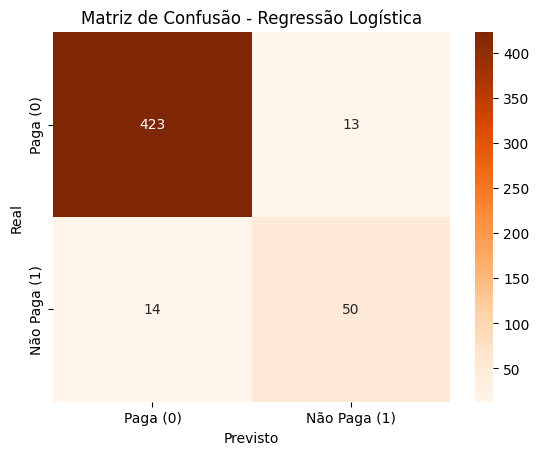


i.   Classificados corretamente que pagam: 423
ii.  Classificados incorretamente como não pagantes: 13
iii. Classificados corretamente que não pagam: 50
iv.  Classificados incorretamente como pagantes: 14

Relatório de classificação (precisão e recall por classe):
              precision    recall  f1-score   support

    Paga (0)       0.97      0.97      0.97       436
Não Paga (1)       0.79      0.78      0.79        64

    accuracy                           0.95       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.95      0.95      0.95       500



In [84]:
# Itens 7 e 8 — Regressão logística em credit.pkl
with open('credit.pkl', 'rb') as f:
    X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

logistic_credit = LogisticRegression(random_state=1, max_iter=1000)
logistic_credit.fit(X_credit_treinamento, y_credit_treinamento)
previsoes_logistic = logistic_credit.predict(X_credit_teste)

acuracia = accuracy_score(y_credit_teste, previsoes_logistic)
print(f"Taxa de acerto (acurácia): {acuracia:.4f}")
print("-" * 50)

cm_logistic = confusion_matrix(y_credit_teste, previsoes_logistic)
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Paga (0)', 'Não Paga (1)'],
    yticklabels=['Paga (0)', 'Não Paga (1)'],
)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

print(f"\ni.   Classificados corretamente que pagam: {cm_logistic[0, 0]}")
print(f"ii.  Classificados incorretamente como não pagantes: {cm_logistic[0, 1]}")
print(f"iii. Classificados corretamente que não pagam: {cm_logistic[1, 1]}")
print(f"iv.  Classificados incorretamente como pagantes: {cm_logistic[1, 0]}")

print("\nRelatório de classificação (precisão e recall por classe):")
print(
    classification_report(
        y_credit_teste,
        previsoes_logistic,
        target_names=['Paga (0)', 'Não Paga (1)'],
    )
)

### Análise (itens 7 e 8)

**Item 7 — taxa de acerto:** o valor impresso na célula anterior é a **acurácia** no conjunto de teste (`credit.pkl`). Com `random_state=1` e `max_iter=1000`, o resultado esperado para este notebook é **0,946** (94,6%).

**Item 8 — comparação com Naive Bayes e com modelos da Parte 2:** use a **matriz de confusão** (heatmap) e o **`classification_report`** acima.

- **Precisão** (por classe): entre os exemplos que o modelo classificou naquela classe, quantos eram realmente dessa classe.
- **Recall** (por classe): entre os exemplos que **realmente** são da classe, quantos o modelo acertou.

Na regressão logística, a classe **Não Paga (1)** costuma ter **recall** menor que **Paga (0)**: há mais **falsos negativos** (cliente não pagador previsto como pagador), visíveis fora da diagonal principal da matriz de confusão.

**Referência na mesma base** (treino/teste da `credit.pkl`):

| Modelo | Acurácia típica (ordem de grandeza) |
|--------|-------------------------------------|
| Naive Bayes (`GaussianNB`, Parte 1) | ~0,938 |
| Regressão logística (esta seção) | **~0,946** |
| Random Forest (10 árvores, Parte 2) | ~0,968 |
| Árvore de decisão (`entropy`, Parte 2) | ~0,98 |

Conclusão: a regressão logística **melhora em relação ao Naive Bayes** em acurácia neste cenário, mas **fica abaixo** da árvore e da floresta, que capturam relações não lineares e interações entre atributos. Para crédito, compare também o **recall da classe “Não Paga”** entre os notebooks: modelos baseados em árvore costumam detectar mais inadimplentes reais (menos falsos negativos), o que se reflete em matrizes de confusão com menos erros nessa linha/coluna.

A regressão logística funciona bem, mas não é a melhor opção para detectar inadimplentes. Modelos mais avançados, como árvores, conseguem melhores resultados.

#PARTE 4: SVM

1. Aplique o algoritmo SVM na base de dados ‘credit.pkl’.
2. Inicialmente treine o SVM com kernel linear, valor do parâmetro C = 1.0 e ‘random_state =1’
3. Utilize o comando do sklearn accuray_score para calcular a acurácia do seu algoritmo. O resultado deve ser 0.946
4. Teste os demais kernels e anote os resultados. Qual o melhor kernel para a sua base de dados?
    * Polinomial
    * Sigmoide
    * rbf
5. Aumente o valor do parâmetro C aplicado ao melhor kernel e verifique se há mudanças no resultado do seu SVM.
6. O Grid Search (pesquisa em grade) é uma técnica utilizada para melhorar a precisão e a generalização dos modelos de aprendizado de máquina. Ela é usada para realizar ajustes de hiperparâmetros durante o treinamento de um modelo. O grid search automatiza o processo de encontrar hiperparâmetros ideais, economizando esforço humano em comparação com o ajuste manual, mas pode até ser mais custoso do ponto de vista de desempenho, pois testa todas as combinações possíveis e retorna a que obteve melhor desempenho.
Agora, aplique o GridSearch do Scikit-Learn (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) para ajudar a identificar os melhores hiperparâmetros para o seu modelo. Qual foi a melhor combinação de hiperparâmetros encontrada? O modelo com melhor desempenho foi obtido com os parâmetros ajustados manualmente ou com o GridSearch?

In [85]:
from sklearn.svm import SVC

## Base de Dados Credit Data

# Análise dos resultados dos 4 algoritmos utilizados:

6. O resultado do SVM é melhor que os resultados do Naive Bayes, Florestas Aleatórias e Regressão Logística? Descreva sua análise de resultados (observe que para isso você deverá visualizar os resultados da Matriz de Confusão, acurácia, precisão e recall).